# 01 · Deep Networks: more than one hidden layer
NumPy for the model · matplotlib for graphs · Runs on Google Colab

1. Same functions, looped over layers ➜ the problem: one hidden layer struggles
2. Stacking layers: shapes and a nudge check
3. Deep vs wide (same number of weights)
4. Vanishing gradients (simple chain ➜ 6-layer network)
5. Real data: digits with 1, 2, 3 hidden layers
6. Experiments

## Setup: activations, softmax, data helpers

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

ACT = {
    "sigmoid": (lambda s: 1 / (1 + np.exp(-s)), lambda s: np.exp(-s) / (1 + np.exp(-s)) ** 2),
    "tanh":    (np.tanh,                         lambda s: 1 - np.tanh(s) ** 2),
    "relu":    (lambda s: np.maximum(0, s),      lambda s: np.where(s > 0, 1.0, 0.0)),
}

def softmax(s):
    e = np.exp(s - s.max())
    return e / e.sum()

def cross_entropy(Y, P):
    return -np.mean(np.log(np.sum(Y * P, axis=1) + 1e-12))

def add_x0(X):
    return np.hstack([-np.ones((len(X), 1)), X])                  # x0 = -1, so w0 is the threshold

def split(X, y, test_ratio=0.2):
    n_test = int(len(X) * test_ratio)
    return X[n_test:], X[:n_test], y[n_test:], y[:n_test]

def make_spirals(n=150, turns=2, noise=0.15):
    X, y = [], []
    for k in range(3):
        r = np.linspace(0.05, 1, n)
        t = np.linspace(0, turns * 2 * np.pi, n) + k * 2 * np.pi / 3 + rng.normal(0, noise, n)
        X.append(np.c_[r * np.sin(t), r * np.cos(t)])
        y += [k] * n
    X, y = np.vstack(X), np.array(y)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

COLORS = ["#e41a1c", "#377eb8", "#4daf4a"]
SHADES = ["#f8d0d0", "#d0e0f4", "#d6efd5"]

def plot_classes(ax, predict, X, y, title):
    g = np.linspace(-1.2, 1.2, 200)
    G1, G2 = np.meshgrid(g, g)
    ax.contourf(G1, G2, predict(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape), levels=[-0.5, 0.5, 1.5, 2.5], colors=SHADES)
    for k in range(3):
        ax.scatter(X[y == k, 0], X[y == k, 1], c=COLORS[k], edgecolors="k", s=12)
    ax.set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), title=title, aspect="equal", xticks=[], yticks=[])

---
# Part 1: the same functions, looped over any number of layers

`sizes = [2, 16, 16, 3]` ➜ 2 inputs, two hidden layers of 16, 3 outputs.

| Function | What it does |
|---|---|
| `forward_pass(x, net)` | for each layer: $s = h \cdot W$, $h = f(s)$; last layer softmax. Keeps every $(h, s)$ |
| `compute_error(y, p)` | $y - p$ |
| `backward_pass(net, error, cache, lr)` | from the last layer back: $dW = -h \otimes \delta$, then $\delta_{prev} = (W \cdot \delta) \times f'(s)$ |
| `train(X, Y, net, lr, epochs)` | shuffled, one sample at a time (SGD) |

In [2]:
def new_net(sizes, act="tanh", scale=1.0):
    return {"act": act, "W": [rng.uniform(-scale, scale, (a + 1, b)) for a, b in zip(sizes[:-1], sizes[1:])]}

def n_weights(net):
    return sum(W.size for W in net["W"])

def forward_pass(x, net):
    f = ACT[net["act"]][0]
    h, cache = x, []
    for W in net["W"][:-1]:
        s = h @ W
        cache.append((h, s))
        h = np.r_[-1, f(s)]                                       # -1 = input for the next layer's threshold
    cache.append((h, None))
    return softmax(h @ net["W"][-1]), cache

def compute_error(y, p):
    return y - p

def backward_pass(net, error, cache, lr):
    df = ACT[net["act"]][1]
    delta, new_W, deltas = error, list(net["W"]), []
    for l in range(len(net["W"]) - 1, -1, -1):                    # last layer ➜ first layer
        h_in = cache[l][0]
        deltas.insert(0, delta)
        dW = -np.outer(h_in, delta)                               # gradient of the loss
        if l > 0:
            delta = (net["W"][l][1:] @ delta) * df(cache[l - 1][1])   # pass the error back through the slope
        new_W[l] = net["W"][l] - lr * dW
    return {"act": net["act"], "W": new_W}, deltas

def predict(P, net):
    f = ACT[net["act"]][0]
    H = add_x0(P)
    for W in net["W"][:-1]:
        H = add_x0(f(H @ W))
    return np.argmax(H @ net["W"][-1], axis=1)


def train(X0, Y, net, lr, epochs, show=True):
    losses = []
    for epoch in range(1, epochs + 1):
        for i in rng.permutation(len(X0)):
            p, cache = forward_pass(X0[i], net)
            net, _ = backward_pass(net, compute_error(Y[i], p), cache, lr)
        losses.append(cross_entropy(Y, np.array([forward_pass(x, net)[0] for x in X0])))
        if show and (epoch == 1 or epoch % max(1, epochs // 5) == 0):
            acc = 100 * (predict(X0[:, 1:], net) == Y.argmax(axis=1)).mean()
            print(f"Epoch {epoch:4d} | loss {losses[-1]:.4f} | train accuracy {acc:5.1f}%")
    return net, losses

def test_acc(net, X, y):
    return 100 * (predict(X, net) == y).mean()

## The problem: tightly wound spirals (2 turns each)

Shape: (450, 2) | train 360, test 90


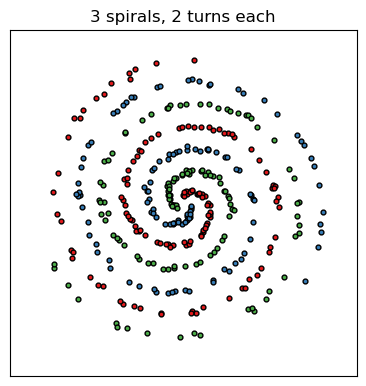

In [3]:
X, y = make_spirals()
Xtr, Xte, ytr, yte = split(X, y)
Xtr0, Ytr = add_x0(Xtr), np.eye(3)[ytr]
print("Shape:", X.shape, f"| train {len(ytr)}, test {len(yte)}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
plot_classes(ax, lambda P: np.zeros(len(P), dtype=int) - 1, Xtr, ytr, "3 spirals, 2 turns each")
plt.show()

## One hidden layer, wider and wider (tanh, η = 0.02, 300 epochs, starting weights ±1)

     network | weights | test acc
---------------------------------
       2-8-3 |      51 |    38.9%
      2-16-3 |      99 |    40.0%
      2-32-3 |     195 |    37.8%
      2-64-3 |     387 |    35.6%


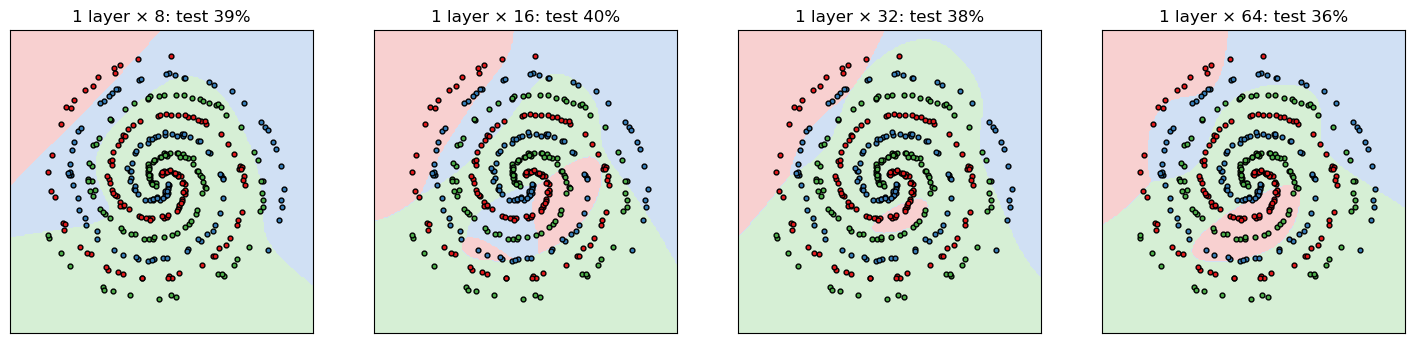

In [4]:
widths = [8, 16, 32, 64]
fig, axes = plt.subplots(1, len(widths), figsize=(18, 4.5))
print(f"{'network':>12} | {'weights':>7} | {'test acc':>8}")
print("-" * 33)
for ax, width in zip(axes, widths):
    net, _ = train(Xtr0, Ytr, new_net([2, width, 3]), 0.02, 300, show=False)
    print(f"{f'2-{width}-3':>12} | {n_weights(net):>7} | {test_acc(net, Xte, yte):7.1f}%")
    plot_classes(ax, lambda P: predict(P, net), Xtr, ytr, f"1 layer × {width}: test {test_acc(net, Xte, yte):.0f}%")
plt.show()

Making one layer wider doesn't help here. **What if we stack layers instead?**

---
# Part 2: stacking layers
## Shape walk: one sample through `[2, 16, 16, 3]`

In [5]:
net = new_net([2, 16, 16, 3])
x, t = Xtr0[0], Ytr[0]
p, cache = forward_pass(x, net)
print("Forward:")
for l, (h, s) in enumerate(cache[:-1]):
    print(f"  layer {l + 1}: input h {h.shape} × W {net['W'][l].shape} -> s {s.shape} -> f(s) {s.shape}")
print(f"  output : input h {cache[-1][0].shape} × W {net['W'][-1].shape} -> softmax -> p {p.shape} = {p}")

_, deltas = backward_pass(net, compute_error(t, p), cache, lr=0.0)
print("\nBackward (δ = error signal at each layer):")
for l in range(len(deltas) - 1, -1, -1):
    name = "output " if l == len(deltas) - 1 else f"layer {l + 1}"
    print(f"  {name}: δ {deltas[l].shape}, average |δ| = {np.abs(deltas[l]).mean():.4f}")

Forward:
  layer 1: input h (3,) × W (3, 16) -> s (16,) -> f(s) (16,)
  layer 2: input h (17,) × W (17, 16) -> s (16,) -> f(s) (16,)
  output : input h (17,) × W (17, 3) -> softmax -> p (3,) = [0.0758 0.8943 0.0299]

Backward (δ = error signal at each layer):
  output : δ (3,), average |δ| = 0.6467
  layer 2: δ (16,), average |δ| = 0.2861
  layer 1: δ (16,), average |δ| = 0.7570


## Nudge check: is the backward pass right for a weight in the **first** layer?

In [6]:
loss_of = lambda n: -np.log(np.sum(t * forward_pass(x, n)[0]))
updated, _ = backward_pass(net, compute_error(t, p), cache, lr=1.0)

for (i, j) in [(1, 0), (2, 5)]:
    nudged = {"act": net["act"], "W": [W.copy() for W in net["W"]]}
    nudged["W"][0][i, j] += 0.0001
    by_nudging = (loss_of(nudged) - loss_of(net)) / 0.0001
    by_backward = net["W"][0][i, j] - updated["W"][0][i, j]       # dW, since W_new = W - 1.0 × dW
    print(f"layer 1, weight [{i},{j}]: slope by nudging = {by_nudging:+.6f} | by backward pass = {by_backward:+.6f}")

layer 1, weight [1,0]: slope by nudging = +0.292686 | by backward pass = +0.292687
layer 1, weight [2,5]: slope by nudging = -0.080950 | by backward pass = -0.080949


---
# Part 3: deep vs wide, about the same number of weights

           network | weights | test acc
----------------------------------------
        [2, 64, 3] |     387 |    47.8%
    [2, 16, 16, 3] |     371 |    92.2%
[2, 12, 12, 12, 3] |     387 |    56.7%
[2, 10, 10, 10, 8, 3] |     365 |    43.3%


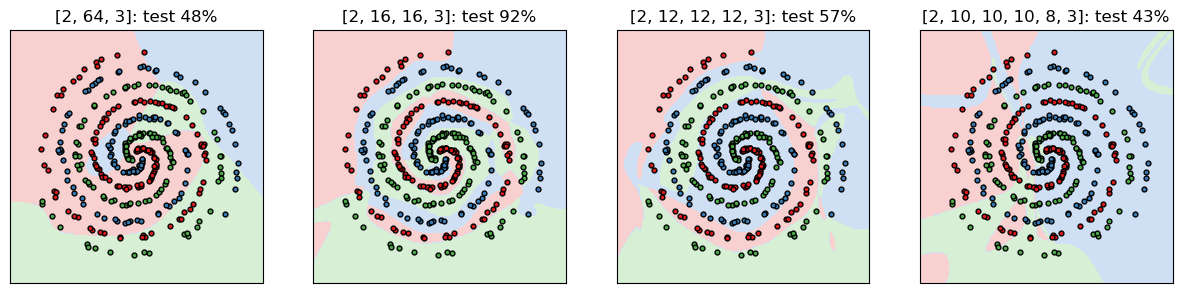

In [7]:
nets = {}
for sizes in [[2, 64, 3], [2, 16, 16, 3], [2, 12, 12, 12, 3], [2, 10, 10, 10, 8, 3]]:
    nets[str(sizes)], _ = train(Xtr0, Ytr, new_net(sizes), 0.02, 300, show=False)

print(f"{'network':>18} | {'weights':>7} | {'test acc':>8}")
print("-" * 40)
for name, net in nets.items():
    print(f"{name:>18} | {n_weights(net):>7} | {test_acc(net, Xte, yte):7.1f}%")

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, (name, net) in zip(axes, nets.items()):
    plot_classes(ax, lambda P: predict(P, net), Xtr, ytr, f"{name}: test {test_acc(net, Xte, yte):.0f}%")
plt.show()

**Fair check:** can the wide network catch up with larger starting weights and more epochs?

In [8]:
wide, _ = train(Xtr0, Ytr, new_net([2, 64, 3], scale=3.0), 0.02, 1000, show=False)
deep, _ = train(Xtr0, Ytr, new_net([2, 16, 16, 3]), 0.02, 1000)
print(f"\n1 layer × 64, start ±3, 1000 epochs : test {test_acc(wide, Xte, yte):.1f}%")
print(f"2 layers × 16, start ±1, 1000 epochs: test {test_acc(deep, Xte, yte):.1f}%")

Epoch    1 | loss 1.1521 | train accuracy  34.2%
Epoch  200 | loss 0.3662 | train accuracy  83.9%
Epoch  400 | loss 0.7624 | train accuracy  83.1%
Epoch  600 | loss 0.0074 | train accuracy 100.0%
Epoch  800 | loss 0.0038 | train accuracy 100.0%
Epoch 1000 | loss 0.0026 | train accuracy 100.0%

1 layer × 64, start ±3, 1000 epochs : test 90.0%
2 layers × 16, start ±1, 1000 epochs: test 95.6%


The wide network *can* learn it, but only from bigger starting weights. The deep one learns from the ordinary start. (Starting weights matter: next notebook.)

---
# Part 4: vanishing gradients
## 4a. A simple chain, by hand

```
x=1 ──w1=1──► (f) ──w2=1──► (f) ──w3=1──► (f) ──w4=1──► (f) ──► y4     target 0
             layer 1      layer 2      layer 3      layer 4
```
Going back, every layer multiplies δ by **weight × slope**: $\delta_{k} = \delta_{k+1} \times w_{k+1} \times f'(s_k)$

In [9]:
def chain(act, x=1.0, target=0.0, weights=(1.0, 1.0, 1.0, 1.0)):
    f, df = ACT[act]
    s, a = [], x
    for w in weights:                                             # forward
        s.append(w * a)
        a = f(s[-1])
    delta = (target - a) * df(s[-1])
    print(f"{act}: forward s = {np.round(s, 4)}, y4 = {a:.4f}")
    print(f"  δ4 = error × f'(s4) = {target - a:+.4f} × {df(s[-1]):.4f} = {delta:+.6f}")
    deltas = [delta]
    for k in range(2, -1, -1):                                    # backward: layers 3, 2, 1
        new = delta * weights[k + 1] * df(s[k])
        print(f"  δ{k + 1} = δ{k + 2} × w{k + 2} × f'(s{k + 1}) = {delta:+.6f} × {weights[k + 1]} × {df(s[k]):.4f} = {new:+.6f}")
        delta = new
        deltas.append(delta)
    print(f"  ➜ δ1 is {abs(deltas[-1] / deltas[0]):.4f} × δ4\n")
    return deltas[::-1]

chain_deltas = {act: chain(act) for act in ACT}

sigmoid: forward s = [1.     0.7311 0.675  0.6626], y4 = 0.6599
  δ4 = error × f'(s4) = -0.6599 × 0.2244 = -0.148102
  δ3 = δ4 × w4 × f'(s3) = -0.148102 × 1.0 × 0.2236 = -0.033108
  δ2 = δ3 × w3 × f'(s2) = -0.033108 × 1.0 × 0.2194 = -0.007263
  δ1 = δ2 × w2 × f'(s1) = -0.007263 × 1.0 × 0.1966 = -0.001428
  ➜ δ1 is 0.0096 × δ4

tanh: forward s = [1.     0.7616 0.642  0.5663], y4 = 0.5126
  δ4 = error × f'(s4) = -0.5126 × 0.7372 = -0.377913
  δ3 = δ4 × w4 × f'(s3) = -0.377913 × 1.0 × 0.6793 = -0.256731
  δ2 = δ3 × w3 × f'(s2) = -0.256731 × 1.0 × 0.5878 = -0.150911
  δ1 = δ2 × w2 × f'(s1) = -0.150911 × 1.0 × 0.4200 = -0.063379
  ➜ δ1 is 0.1677 × δ4

relu: forward s = [1. 1. 1. 1.], y4 = 1.0000
  δ4 = error × f'(s4) = -1.0000 × 1.0000 = -1.000000
  δ3 = δ4 × w4 × f'(s3) = -1.000000 × 1.0 × 1.0000 = -1.000000
  δ2 = δ3 × w3 × f'(s2) = -1.000000 × 1.0 × 1.0000 = -1.000000
  δ1 = δ2 × w2 × f'(s1) = -1.000000 × 1.0 × 1.0000 = -1.000000
  ➜ δ1 is 1.0000 × δ4



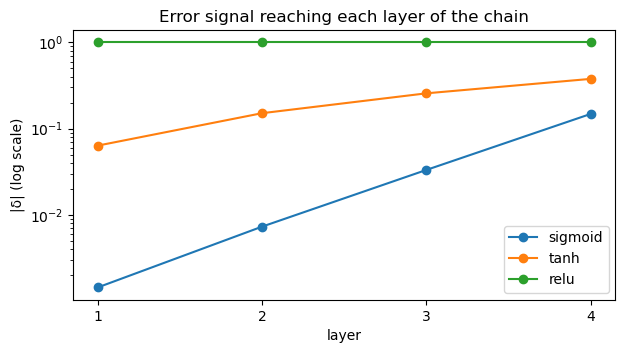

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for act, d in chain_deltas.items():
    ax.plot([1, 2, 3, 4], np.abs(d), "o-", label=act)
ax.set(yscale="log", xticks=[1, 2, 3, 4], xlabel="layer", ylabel="|δ| (log scale)", title="Error signal reaching each layer of the chain")
ax.legend()
plt.show()

## 4b. The same effect in a 6-hidden-layer network `[2, 16, 16, 16, 16, 16, 16, 3]`

sigmoid: average |δ| from layer 1 to output = [0.0012 0.0026 0.0069 0.0149 0.0265 0.0673 0.4371]
   tanh: average |δ| from layer 1 to output = [1.0583 0.5542 0.3085 0.2077 0.1475 0.1382 0.4416]
   relu: average |δ| from layer 1 to output = [1.6279 0.8476 0.5342 0.4449 0.3723 0.2224 0.4455]


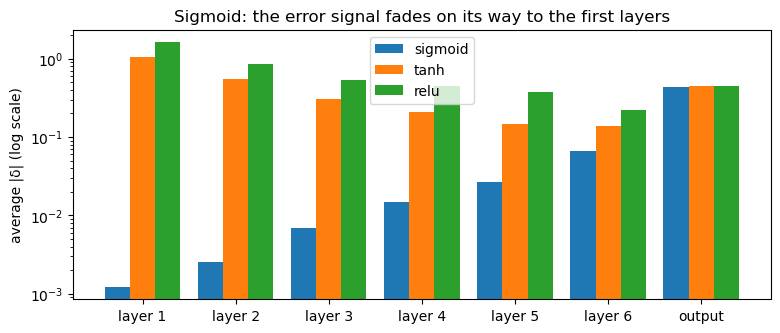

In [11]:
deep_sizes = [2] + [16] * 6 + [3]

def average_deltas(net):
    total = np.zeros(len(net["W"]))
    for x, t in zip(Xtr0, Ytr):
        p, cache = forward_pass(x, net)
        _, deltas = backward_pass(net, compute_error(t, p), cache, lr=0.0)
        total += [np.abs(d).mean() for d in deltas]
    return total / len(Xtr0)

fig, ax = plt.subplots(figsize=(9, 3.5))
for k, act in enumerate(ACT):
    avg = average_deltas(new_net(deep_sizes, act))
    print(f"{act:>7}: average |δ| from layer 1 to output = {avg}")
    ax.bar(np.arange(1, 8) + (k - 1) * 0.27, avg, width=0.27, label=act)
ax.set(yscale="log", xticks=range(1, 8), xticklabels=[f"layer {i}" for i in range(1, 7)] + ["output"],
       ylabel="average |δ| (log scale)", title="Sigmoid: the error signal fades on its way to the first layers")
ax.legend()
plt.show()

## 4c. Train the 6-layer network with each activation (150 epochs)

sigmoid (η = 0.02): test accuracy  26.7%
   tanh (η = 0.02): test accuracy  26.7%
   relu (η = 0.005): test accuracy  54.4%


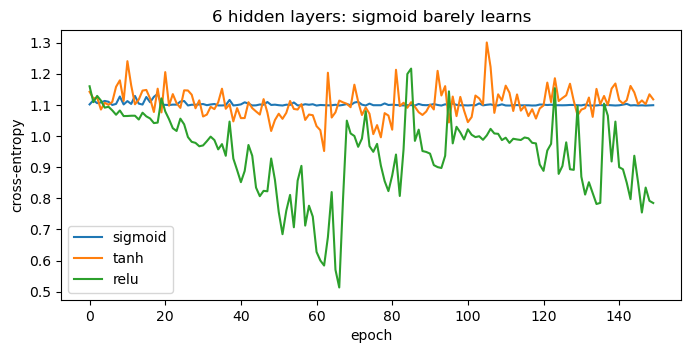

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for act, lr in [("sigmoid", 0.02), ("tanh", 0.02), ("relu", 0.005)]:
    net, losses = train(Xtr0, Ytr, new_net(deep_sizes, act), lr, 150, show=False)
    print(f"{act:>7} (η = {lr}): test accuracy {test_acc(net, Xte, yte):5.1f}%")
    ax.plot(losses, label=act)
ax.set(xlabel="epoch", ylabel="cross-entropy", title="6 hidden layers: sigmoid barely learns")
ax.legend()
plt.show()

Sigmoid: δ at layer 1 is ~600× smaller than at the output, so the first layers barely learn. tanh and ReLU don't vanish (ReLU's δ even **grows** going back), yet none of the 6-layer networks gets near the 2-layer result: deep networks need **better starting weights** ➜ next notebook.

---
# Part 5: real data — handwritten digits with 1, 2, 3 hidden layers

In [13]:
import io, urllib.request

def load_digits(name):
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/" + name
    d = np.genfromtxt(io.StringIO(urllib.request.urlopen(url).read().decode()), delimiter=",").astype(int)
    return d[:, :64] / 16, d[:, 64]

Xd_tr, yd_tr = load_digits("optdigits.tra")
Xd_te, yd_te = load_digits("optdigits.tes")
Xd_tr0, Yd_tr = add_x0(Xd_tr), np.eye(10)[yd_tr]
print(f"train {Xd_tr.shape}, test {Xd_te.shape}")

print(f"\n{'network':>20} | {'weights':>7} | {'test acc':>8} | {'time':>6}")
print("-" * 52)
for sizes in [[64, 32, 10], [64, 32, 32, 10], [64, 32, 32, 32, 10]]:
    start = time.time()
    net, _ = train(Xd_tr0, Yd_tr, new_net(sizes, scale=0.5), 0.02, 10, show=False)
    print(f"{str(sizes):>20} | {n_weights(net):>7} | {test_acc(net, Xd_te, yd_te):7.1f}% | {time.time() - start:5.1f}s")

train (3823, 64), test (1797, 64)

             network | weights | test acc |   time
----------------------------------------------------
        [64, 32, 10] |    2410 |    95.6% |   1.7s
    [64, 32, 32, 10] |    3466 |    95.4% |   2.6s
[64, 32, 32, 32, 10] |    4522 |    96.0% |   3.4s


Digits are already easy for one hidden layer, so extra layers add little here; depth pays off on harder patterns like the spirals.

---
# Part 6: Experiments (spirals)
## 1. Depth: 1 to 4 hidden layers of 16 (tanh, η = 0.02, 300 epochs)

1 hidden layer(s):   99 weights | test accuracy  42.2%
2 hidden layer(s):  371 weights | test accuracy  96.7%
3 hidden layer(s):  643 weights | test accuracy  91.1%
4 hidden layer(s):  915 weights | test accuracy  76.7%


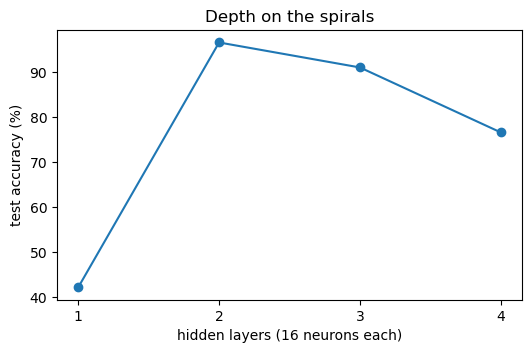

In [14]:
depths = [1, 2, 3, 4]
accs = []
for d in depths:
    net, _ = train(Xtr0, Ytr, new_net([2] + [16] * d + [3]), 0.02, 300, show=False)
    accs.append(test_acc(net, Xte, yte))
    print(f"{d} hidden layer(s): {n_weights(net):>4} weights | test accuracy {accs[-1]:5.1f}%")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(depths, accs, "o-")
ax.set(xticks=depths, xlabel="hidden layers (16 neurons each)", ylabel="test accuracy (%)", title="Depth on the spirals")
plt.show()

More layers isn't automatically better: with these starting weights, 2 hidden layers learn best; 3–4 learn more slowly.

## 2. Learning rate for `[2, 16, 16, 3]` (same start, 300 epochs)

η = 0.002: test accuracy  41.1%
η = 0.02 : test accuracy  95.6%
η = 0.1  : test accuracy  44.4%
η = 0.5  : test accuracy  34.4%


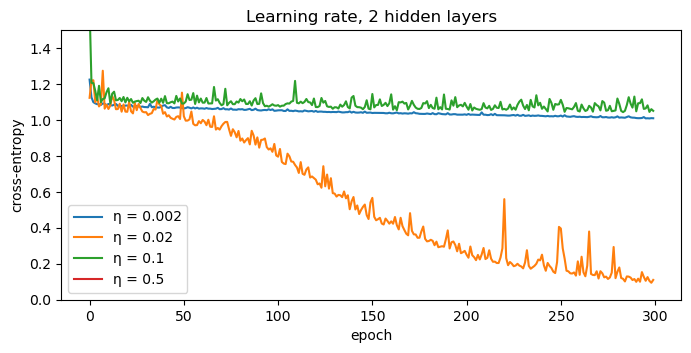

In [15]:
start = new_net([2, 16, 16, 3])
fig, ax = plt.subplots(figsize=(8, 3.5))
for lr in [0.002, 0.02, 0.1, 0.5]:
    net, losses = train(Xtr0, Ytr, start, lr, 300, show=False)
    print(f"η = {lr:<5}: test accuracy {test_acc(net, Xte, yte):5.1f}%")
    ax.plot(losses, label=f"η = {lr}")
ax.set(xlabel="epoch", ylabel="cross-entropy", ylim=(0, 1.5), title="Learning rate, 2 hidden layers")
ax.legend()
plt.show()